In [ ]:
import pandas as pd

df = pd.read_excel("data/Online Retail.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Rows and Columns: (541909, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


# Country-wise Order Analysis

This graph shows the number of orders placed from different countries. It helps understand customer distribution and order frequency across regions.

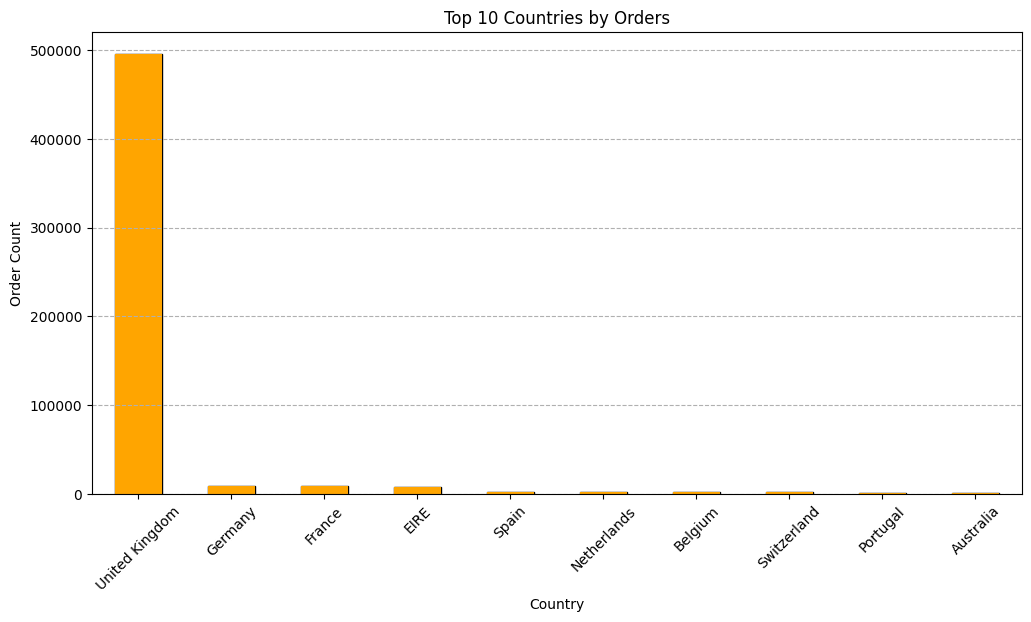

In [ ]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(12,6))
top_countries.plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by Orders")
top_countries.plot(kind="bar", color="orange")
plt.xlabel("Country")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

plt.show()

# Top Selling Products Analysis

This graph shows the 10 most frequently purchased products. It helps identify customer preferences and the products with the highest demand in the retail store.

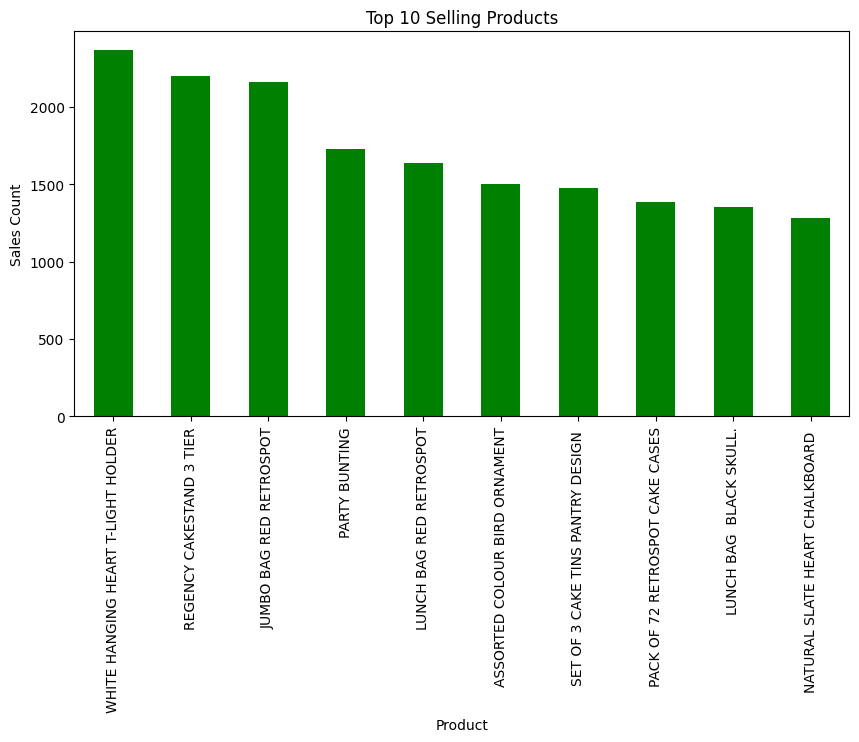

In [ ]:
top_products = df["Description"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar", color="Green")
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales Count")
plt.xticks(rotation=90)
plt.show()

# Country-wise Sales Quantity Analysis
This graph represents the total quantity of products sold across different countries. It helps identify the countries contributing the highest sales volume.


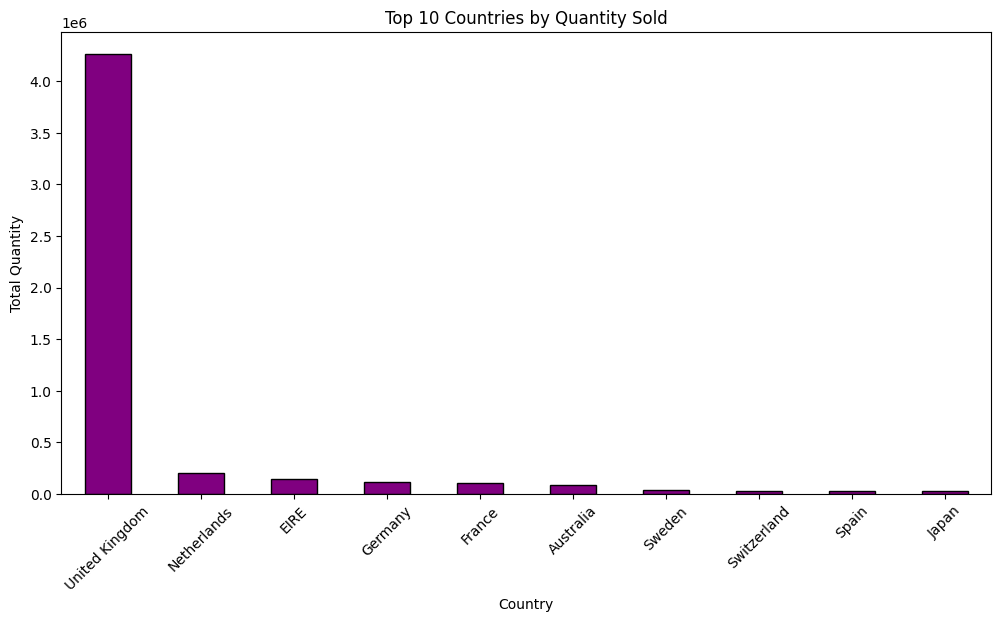

In [ ]:
sales_by_country = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sales_by_country.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Top 10 Countries by Quantity Sold")
plt.xlabel("Country")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)

plt.show()

# Monthly Sales Trend Analysis

This graph illustrates the month-wise quantity of products sold. It helps analyze seasonal demand patterns and sales fluctuations throughout the year.

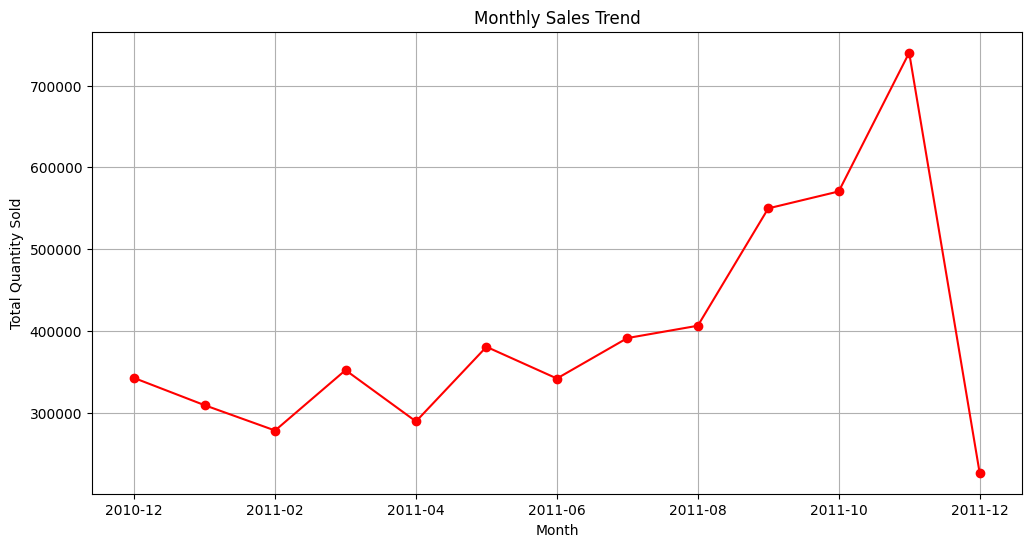

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

monthly_sales = df.groupby(
    df["InvoiceDate"].dt.to_period("M")
)["Quantity"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))

monthly_sales.plot(
    kind="line",
    color="red",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.grid(True)

plt.show()

# Monthly Sales Growth Analysis

This graph highlights the trend of product sales over different months. It helps evaluate business performance and identify periods of high customer demand.

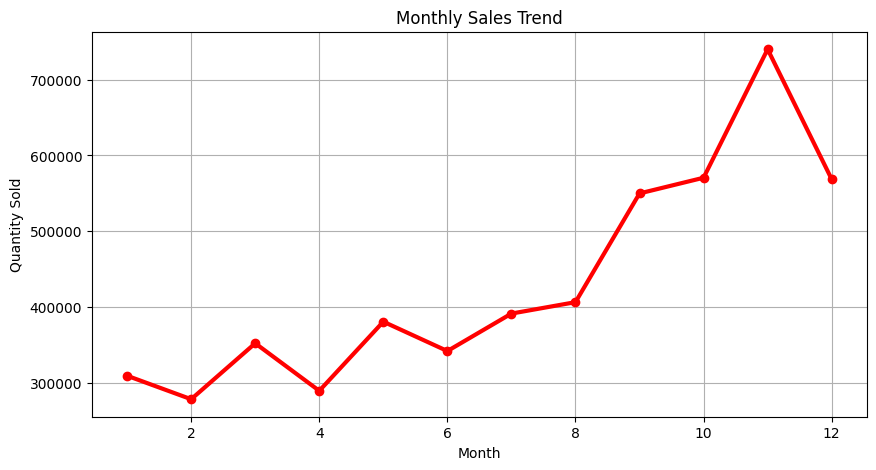

In [ ]:
monthly_sales = df.groupby(df["InvoiceDate"].dt.month)["Quantity"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(
    kind="line",
    color="red",
    marker="o",
    linewidth=3
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.grid(True)git add .
git commit -m "Updated EDA notebook"
git push
plt.show()

In [ ]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
df = df.dropna()

print("New Shape:", df.shape)

New Shape: (406829, 8)


In [ ]:
df.duplicated().sum()

np.int64(5225)

In [ ]:
df = df.drop_duplicates()

print("Final Shape:", df.shape)

Final Shape: (401604, 8)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
import matplotlib.pyplot as plt

# Top Customers by Spending Analysis

This graph displays the top 10 customers based on their total spending. It helps identify high-value customers who contribute significantly to business revenue.

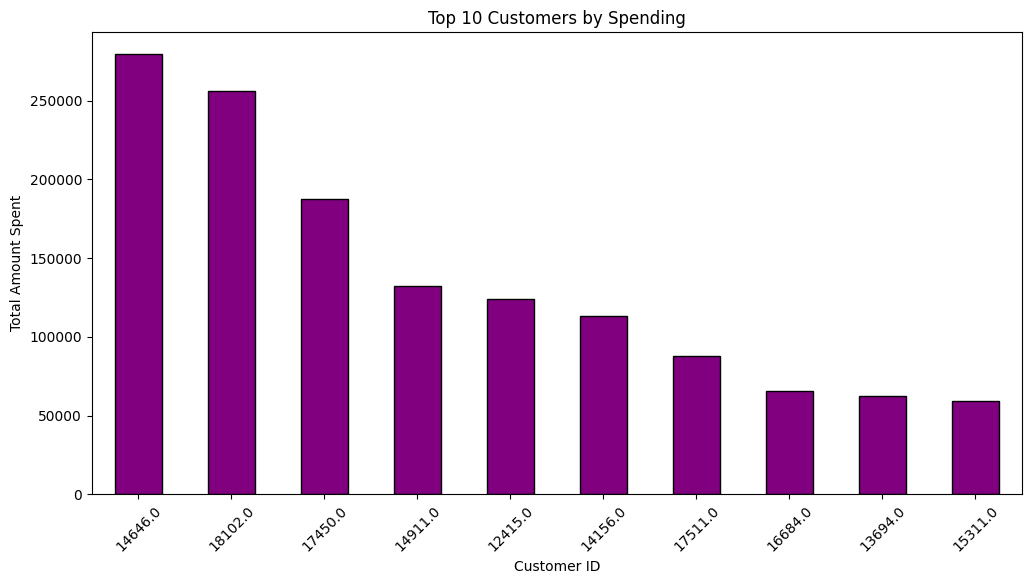

In [ ]:
customer_sales = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
customer_sales.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=45)
plt.show()

# Top Products by Revenue Analysis

This graph shows the products generating the highest revenue. It helps identify the most profitable products in the retail business.

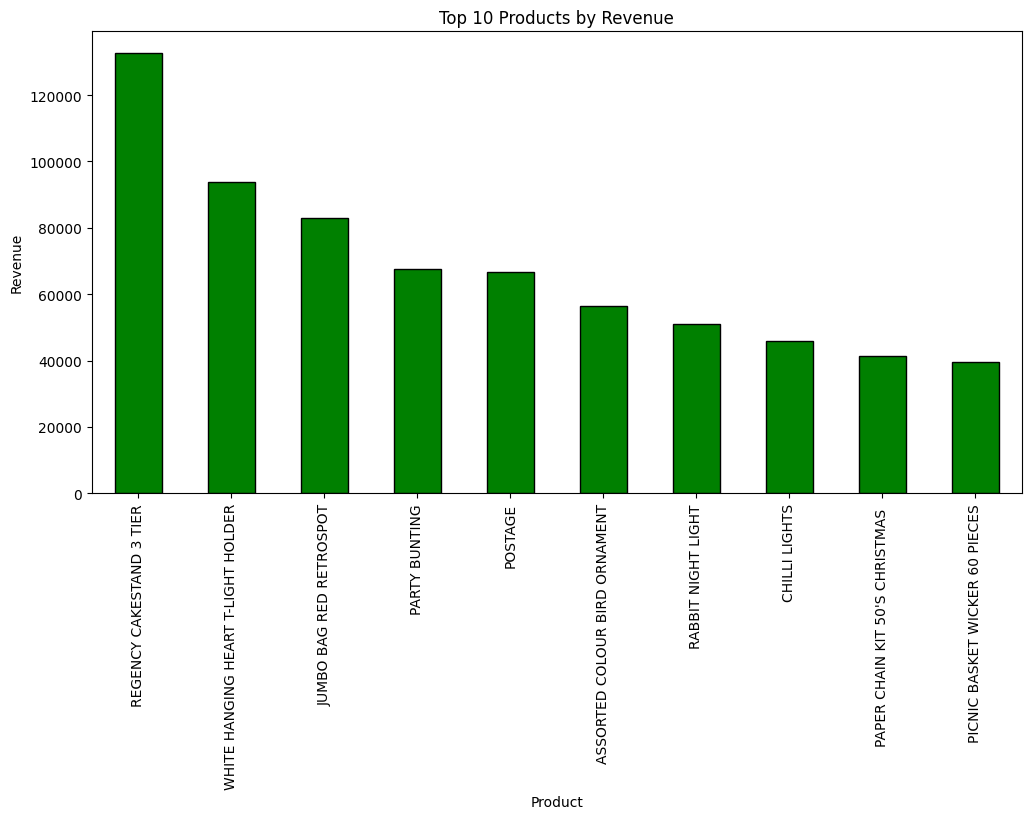

In [ ]:
top_products_revenue = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products_revenue.plot(
    kind="bar",
    color="green",
    edgecolor="black"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

# Country-wise Revenue Analysis

This graph represents the total revenue generated from different countries. It helps determine the most profitable geographic markets.

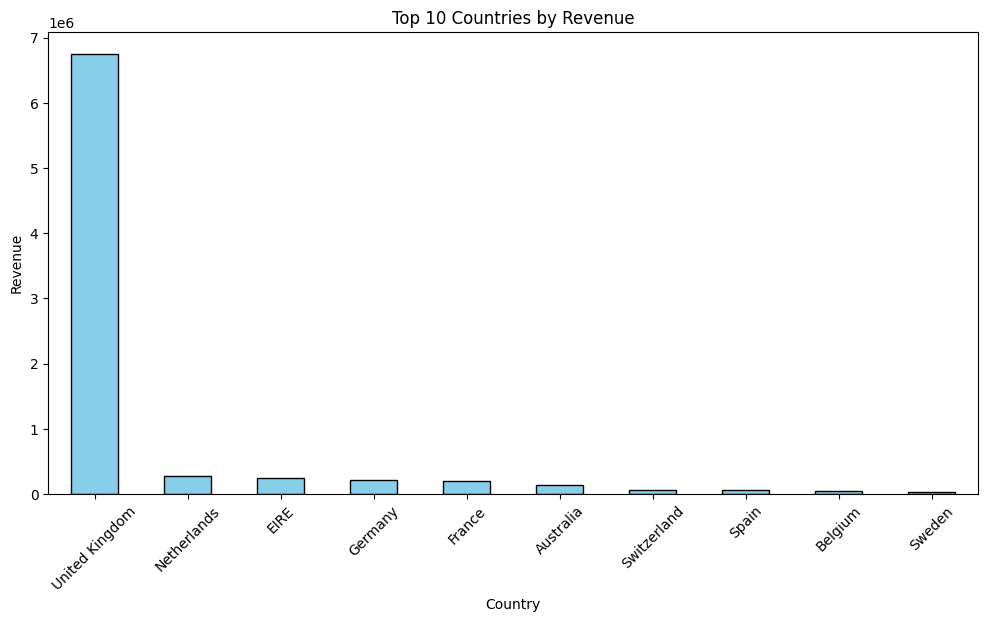

In [ ]:
country_revenue = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
country_revenue.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Monthly Revenue Trend Analysis

This graph illustrates the monthly revenue generated throughout the year. It helps identify revenue growth patterns and peak business periods.

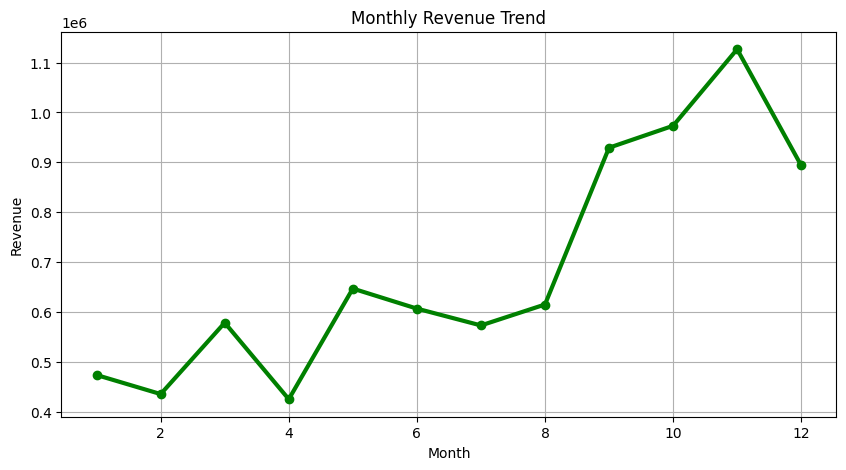

In [ ]:
monthly_revenue = df.groupby(df["InvoiceDate"].dt.month)["TotalPrice"].sum()

plt.figure(figsize=(10,5))

monthly_revenue.plot(
    kind="line",
    
    color="green",
    marker="o",
    linewidth=3
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Demand Forecasting using Machine Learning

This section predicts future sales trends based on historical transaction data. The model helps retailers estimate future demand and make inventory decisions.

In [ ]:
monthly_data = df.groupby(df['InvoiceDate'].dt.month)['TotalPrice'].sum().reset_index()

monthly_data.columns = ['Month', 'Revenue']

monthly_data

,Month,Revenue
0,1,560000.260
1,2,498062.650
2,3,683267.080
3,4,493207.121
4,5,723333.510
5,6,691123.120
6,7,681300.111
7,8,682680.510
8,9,1019687.622
9,10,1070704.670


In [ ]:
X = monthly_data[['Month']]
y = monthly_data['Revenue']

print(X.head())
print(y.head())

   Month
0      1
1      2
2      3
3      4
4      5
0    560000.260
1    498062.650
2    683267.080
3    493207.121
4    723333.510
Name: Revenue, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[1037997.31834497  975516.17622626  413185.89715782]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 221920.59609031645
R2 Score: 0.4860553767016903


# Actual vs Predicted Revenue Analysis

This graph compares the actual revenue values with the revenue predicted by the machine learning model. It helps evaluate the forecasting performance of the model.

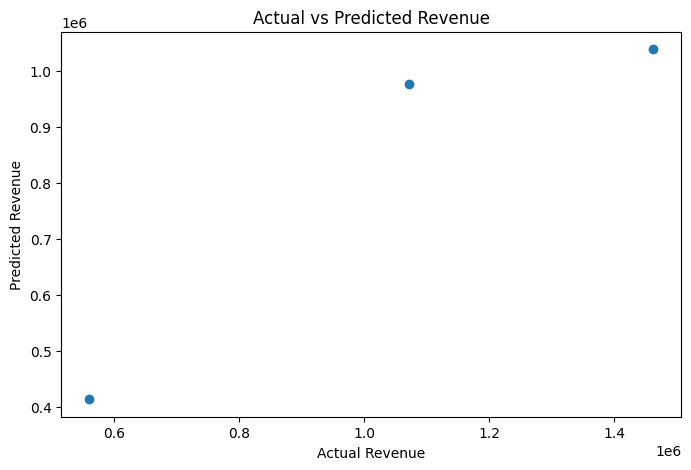

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 221920.59609031645
R2 Score: 0.4860553767016903


# Future Revenue Forecast

This section predicts the expected revenue for upcoming months using historical sales data and Linear Regression. The forecast helps businesses plan inventory and sales strategies.

In [ ]:
future_months = pd.DataFrame({
    'Month':[13,14,15]
})

future_predictions = model.predict(future_months)

print("Future Revenue Predictions:")
print(future_predictions)

Future Revenue Predictions:
[1162959.6025824  1225440.74470112 1287921.88681983]


In [ ]:
import os

os.makedirs("models", exist_ok=True)

In [ ]:
import pickle

with open("models/forecast_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved Successfully")

Model Saved Successfully


# Customer Segmentation using K-Means

This section groups customers based on their purchasing behavior using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering. Customer segmentation helps retailers identify high-value, loyal, and at-risk customers for targeted marketing and retention strategies.

In [ ]:
import pandas as pd
import numpy as np

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='str')

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
rfm = rfm.dropna()

print(rfm.shape)

(4372, 3)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print(rfm_scaled[:5])

[[ 2.32202285 -0.32936215 -0.23100099]
 [-0.89373323  0.20610242  0.29343167]
 [-0.1691956  -0.11517632 -0.01231622]
 [-0.72500529 -0.43645506 -0.01714563]
 [ 2.16322008 -0.43645506 -0.19031183]]


# Customer Segmentation Analysis

The Elbow Method is used to determine the optimal number of customer clusters. The point where the curve begins to flatten indicates the ideal number of segments for grouping customers based on purchasing behavior.

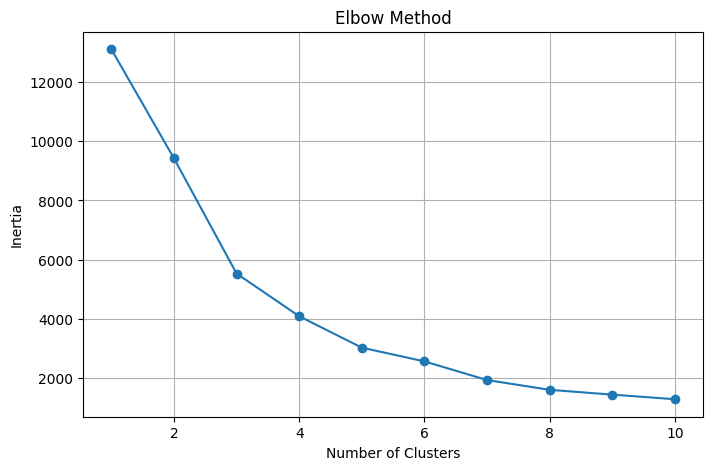

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


# Customer Segments Visualization

This graph groups customers into different clusters based on purchase frequency and total spending. Businesses can use these segments to identify loyal customers, premium buyers, and customers who may require retention strategies.

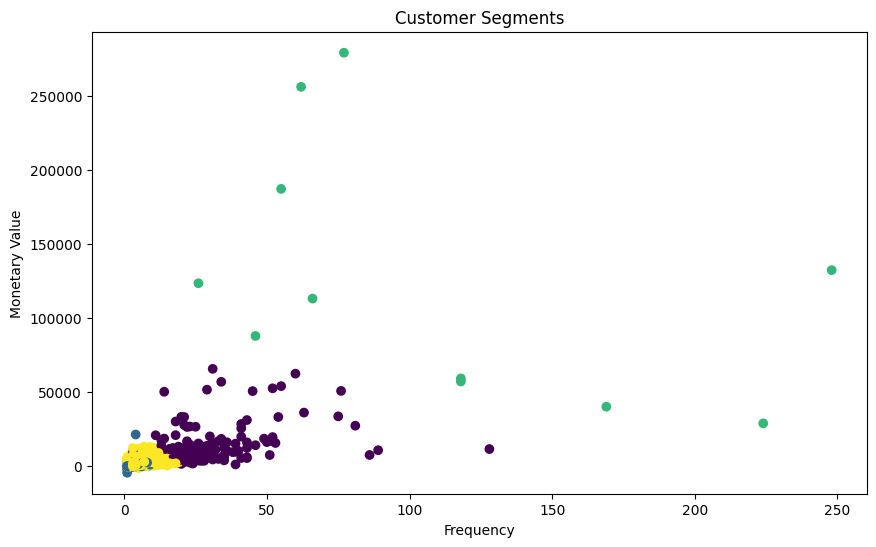

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Segments")
plt.show()

In [ ]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,10.752577,28.510309,12168.264691
1,248.927577,1.805942,455.110716
2,5.090909,109.909091,124312.306364
3,42.780906,4.370550,1320.981506


# Cluster Spending Analysis

This graph shows the average spending (Monetary Value) of customers in each cluster. It helps identify high-value customer groups that contribute the most revenue and can be targeted for loyalty programs and personalized marketing.

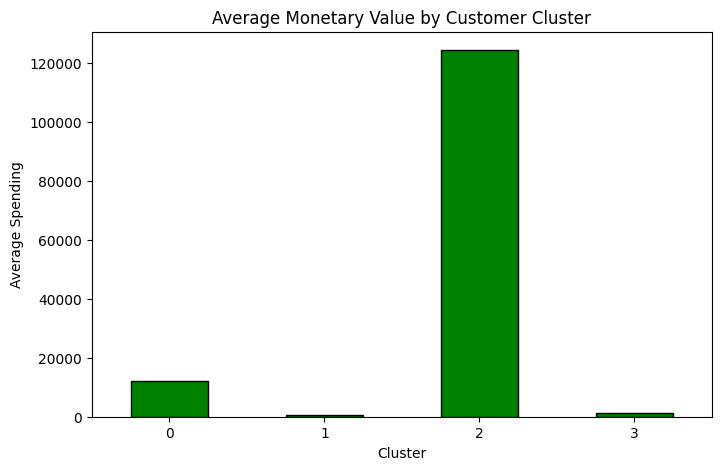

In [ ]:
plt.figure(figsize=(8,5))

cluster_summary['Monetary'].plot(
    kind='bar',
    color='green',
    edgecolor='black'
)

plt.title("Average Monetary Value by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Spending")
plt.xticks(rotation=0)

plt.show()

# Customer Churn Prediction

This section identifies customers who are likely to stop purchasing from the store. Customers with high recency values and low purchase frequency are considered at risk of churn. This analysis helps businesses improve customer retention through targeted marketing campaigns and loyalty programs.

In [ ]:
rfm["Churn"] = np.where(
    (rfm["Recency"] > rfm["Recency"].median()) &
    (rfm["Frequency"] < rfm["Frequency"].median()),
    1,
    0
)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Churn
CustomerID,,,,,
12346.0,326,2,0.00,1,1
12347.0,2,7,4310.00,3,0
12348.0,75,4,1797.24,3,0
12349.0,19,1,1757.55,3,0
12350.0,310,1,334.40,1,1


In [ ]:
rfm["Churn"].value_counts()

Churn
0    2888
1    1484
Name: count, dtype: int64

# Customer Churn Distribution

This graph displays the number of active and churn-risk customers. It helps businesses understand customer retention performance and identify the percentage of customers likely to leave.

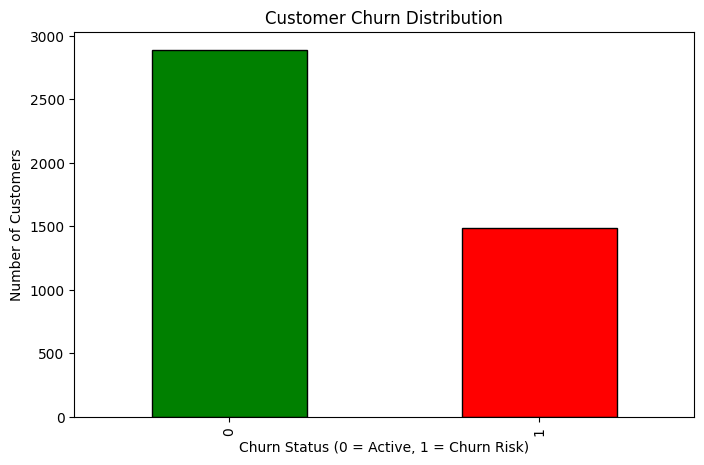

In [ ]:
plt.figure(figsize=(8,5))

rfm["Churn"].value_counts().plot(
    kind="bar",
    color=["green","red"],
    edgecolor="black"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status (0 = Active, 1 = Churn Risk)")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
plt.savefig("graph14.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
X = rfm[["Recency","Frequency","Monetary"]]
y = rfm["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
churn_model = RandomForestClassifier(random_state=42)

churn_model.fit(X_train, y_train)

print("Churn Model Trained Successfully")

Churn Model Trained Successfully


In [ ]:
y_pred = churn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


# Feature Importance Analysis

This graph shows which customer behavior metrics contribute most to churn prediction. Understanding these factors helps businesses focus on retention strategies more effectively.

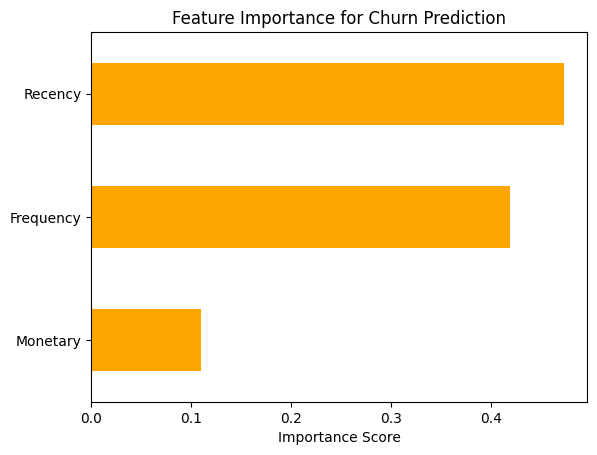

In [ ]:
importance = pd.Series(
    churn_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    color="orange"
)

plt.title("Feature Importance for Churn Prediction")
plt.xlabel("Importance Score")

plt.show()

In [ ]:
plt.savefig("graph15.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Inventory Optimization Analysis

This section analyzes product demand and inventory movement patterns. The analysis helps businesses identify fast-moving products that require frequent restocking and slow-moving products that may lead to excess inventory costs.

In [ ]:
inventory_data = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

inventory_data.head()

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS    53847
JUMBO BAG RED RETROSPOT              47363
ASSORTED COLOUR BIRD ORNAMENT        36381
POPCORN HOLDER                       36334
PACK OF 72 RETROSPOT CAKE CASES      36039
Name: Quantity, dtype: int64

In [ ]:
top_inventory = inventory_data.head(10)

top_inventory

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64

# Top Fast-Moving Products

This graph displays the products with the highest sales quantity. These products should be prioritized for inventory replenishment to prevent stock shortages and lost sales opportunities.

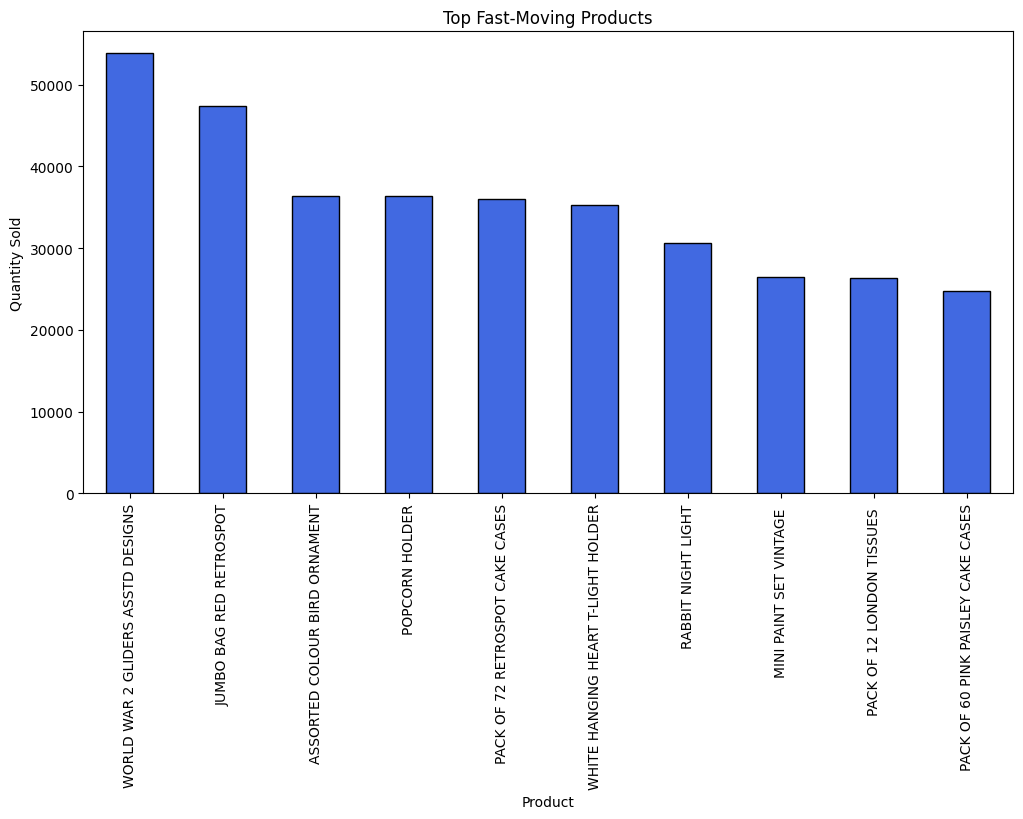

In [ ]:
plt.figure(figsize=(12,6))

top_inventory.plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title("Top Fast-Moving Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=90)

plt.show()

In [ ]:
plt.savefig("graph16.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
slow_inventory = inventory_data.tail(10)

slow_inventory

Description
wrongly marked. 23343 in box    -3100
thrown away                     -4110
incorrect stock entry.          -4320
damages                         -4338
throw away                      -5368
Damaged                         -7540
Printing smudges/thrown away    -9058
check                          -12030
Unsaleable, destroyed.         -15644
printing smudges/thrown away   -19200
Name: Quantity, dtype: int64

# Slow-Moving Products

This graph highlights products with the lowest sales quantity. These items may require promotional strategies, discounts, or inventory reduction measures to minimize holding costs.

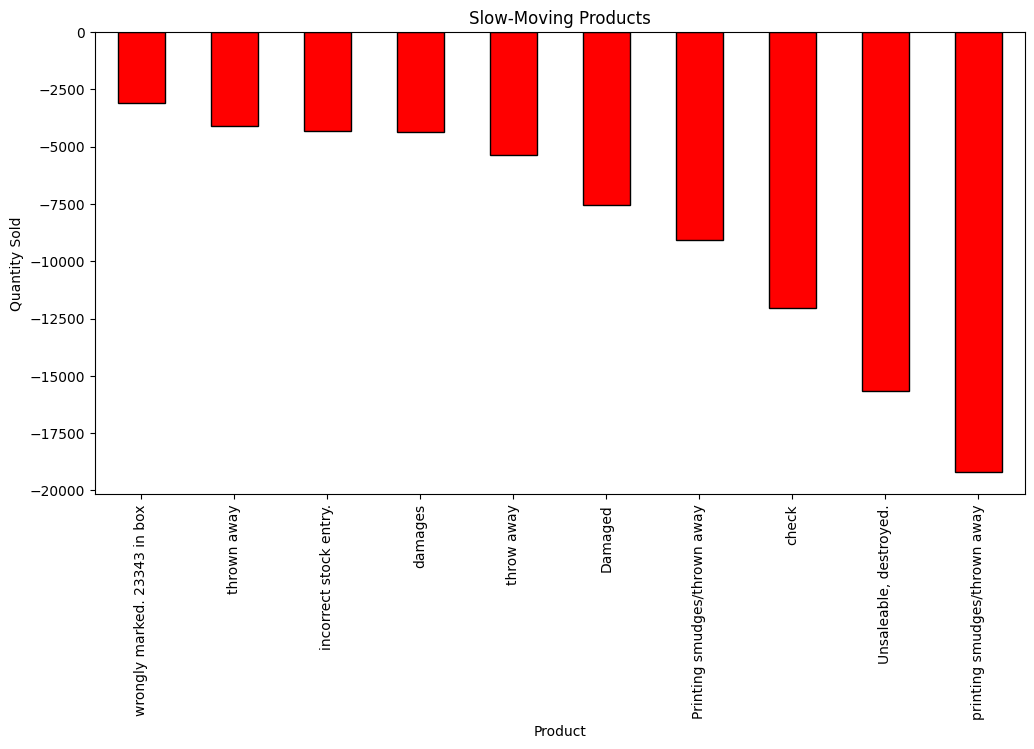

In [ ]:
plt.figure(figsize=(12,6))

slow_inventory.plot(
    kind="bar",
    color="red",
    edgecolor="black"
)

plt.title("Slow-Moving Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=90)

plt.show()

In [ ]:
plt.savefig("graph17.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
inventory_report = pd.DataFrame({
    "Product": inventory_data.index,
    "Quantity Sold": inventory_data.values
})

inventory_report["Inventory Status"] = np.where(
    inventory_report["Quantity Sold"] > inventory_report["Quantity Sold"].median(),
    "Restock Required",
    "Slow Moving"
)

inventory_report.head(20)

,Product,Quantity Sold,Inventory Status
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847,Restock Required
1,JUMBO BAG RED RETROSPOT,47363,Restock Required
2,ASSORTED COLOUR BIRD ORNAMENT,36381,Restock Required
3,POPCORN HOLDER,36334,Restock Required
4,PACK OF 72 RETROSPOT CAKE CASES,36039,Restock Required
5,WHITE HANGING HEART T-LIGHT HOLDER,35317,Restock Required
6,RABBIT NIGHT LIGHT,30680,Restock Required
7,MINI PAINT SET VINTAGE,26437,Restock Required
8,PACK OF 12 LONDON TISSUES,26315,Restock Required
9,PACK OF 60 PINK PAISLEY CAKE CASES,24753,Restock Required


# Product Recommendation System

This section recommends products based on purchasing patterns observed in historical transaction data. The recommendation system helps retailers improve customer experience, increase sales, and support personalized marketing strategies.

In [3]:
import pandas as pd

df = pd.read_excel("data/Online Retail.xlsx")

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


In [5]:
basket = df.groupby(
    ['InvoiceNo', 'Description']
)['Quantity'].sum().unstack().fillna(0)

basket = (basket > 0).astype(int)

print(basket.shape)

(24446, 4223)


In [6]:
top_products = basket.sum().sort_values(ascending=False).head(100).index

basket_small = basket[top_products]

product_similarity = basket_small.corr()

print(product_similarity.shape)

(100, 100)


In [7]:
def recommend(product_name):
    return product_similarity[product_name].sort_values(
        ascending=False
    ).head(6)

In [8]:
print(product_similarity.columns[:20])

Index(['WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT',
       'REGENCY CAKESTAND 3 TIER', 'PARTY BUNTING', 'LUNCH BAG RED RETROSPOT',
       'ASSORTED COLOUR BIRD ORNAMENT', 'SET OF 3 CAKE TINS PANTRY DESIGN ',
       'PACK OF 72 RETROSPOT CAKE CASES', 'LUNCH BAG  BLACK SKULL.',
       'NATURAL SLATE HEART CHALKBOARD ', 'JUMBO BAG PINK POLKADOT',
       'HEART OF WICKER SMALL', 'JUMBO STORAGE BAG SUKI',
       'JUMBO SHOPPER VINTAGE RED PAISLEY', 'JAM MAKING SET PRINTED',
       'PAPER CHAIN KIT 50'S CHRISTMAS ', 'LUNCH BAG SPACEBOY DESIGN ',
       'LUNCH BAG CARS BLUE', 'SPOTTY BUNTING', 'JAM MAKING SET WITH JARS'],
      dtype='object', name='Description')


In [9]:
recommend('WHITE HANGING HEART T-LIGHT HOLDER')

Description
WHITE HANGING HEART T-LIGHT HOLDER    1.000000
RED HANGING HEART T-LIGHT HOLDER      0.351317
WOODEN PICTURE FRAME WHITE FINISH     0.208674
HEART OF WICKER LARGE                 0.201505
NATURAL SLATE HEART CHALKBOARD        0.192114
HEART OF WICKER SMALL                 0.182931
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [10]:
product_similarity.columns[0]

'WHITE HANGING HEART T-LIGHT HOLDER'

In [11]:
recommend(product_similarity.columns[0])

Description
WHITE HANGING HEART T-LIGHT HOLDER    1.000000
RED HANGING HEART T-LIGHT HOLDER      0.351317
WOODEN PICTURE FRAME WHITE FINISH     0.208674
HEART OF WICKER LARGE                 0.201505
NATURAL SLATE HEART CHALKBOARD        0.192114
HEART OF WICKER SMALL                 0.182931
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

# Product Recommendation System

This section recommends products based on customer purchasing behavior. Product similarity analysis is used to identify items that are frequently purchased together, helping retailers improve customer experience and increase sales through personalized recommendations.

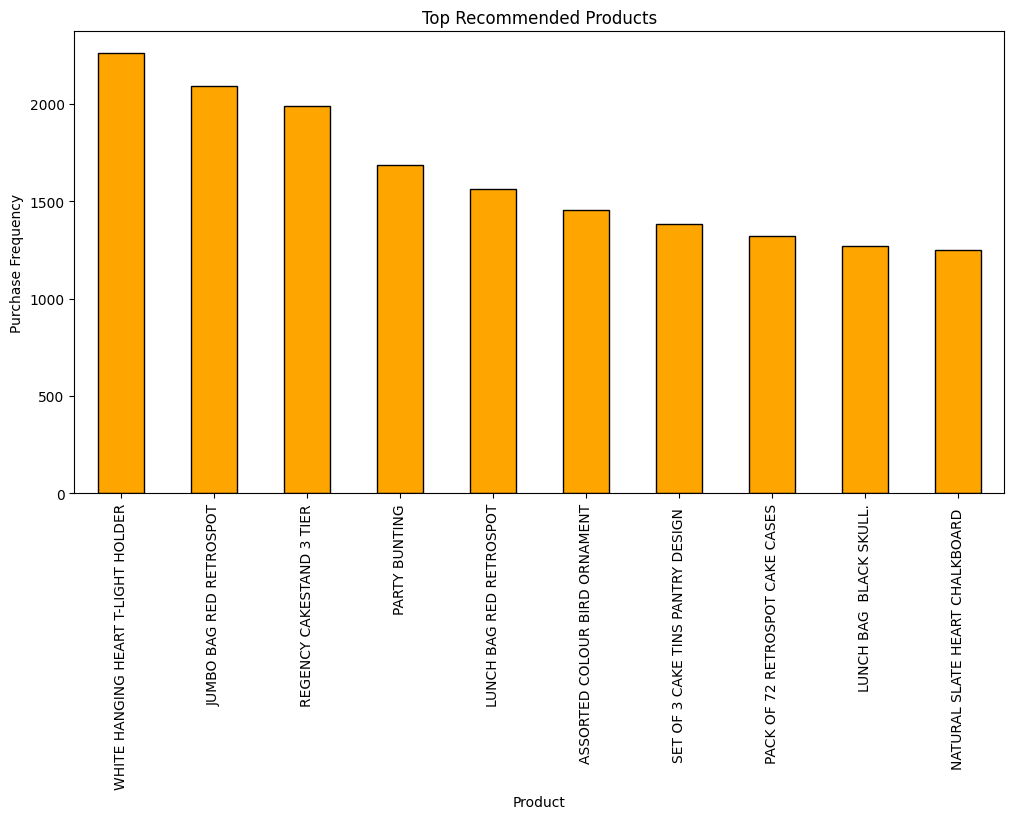

In [12]:
import matplotlib.pyplot as plt

popular_products = basket.sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

popular_products.plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)

plt.title("Top Recommended Products")
plt.xlabel("Product")
plt.ylabel("Purchase Frequency")
plt.xticks(rotation=90)

plt.show()

In [13]:
plt.savefig("graph19.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# Customer Churn Prediction

This section identifies customers who are at risk of becoming inactive based on their purchasing behavior. Predicting customer churn helps businesses improve retention strategies and maintain long-term customer relationships.

In [15]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [16]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='str')


In [17]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_data = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

customer_data.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

customer_data.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [18]:
customer_data['Churn'] = (
    customer_data['Recency'] > 90
).astype(int)

customer_data.head()

,Recency,Frequency,Monetary,Churn
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [19]:
X = customer_data[
    ['Recency', 'Frequency', 'Monetary']
]

y = customer_data['Churn']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


# Customer Churn Distribution Analysis

This graph shows the number of active and churned customers. Churned customers are identified based on inactivity over a specified period. Businesses can use this information to improve customer retention strategies.

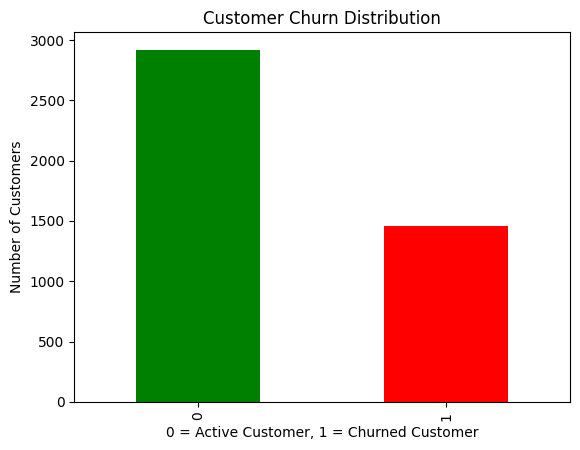

In [24]:
import matplotlib.pyplot as plt

customer_data['Churn'].value_counts().plot(
    kind='bar',
    color=['green', 'red']
)

plt.title("Customer Churn Distribution")
plt.xlabel("0 = Active Customer, 1 = Churned Customer")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
plt.savefig("graph19.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>